# Indian Banking Customer Segmentation & Marketing Analytics

## Project Overview

This project analyzes customer transaction data to identify distinct customer segments and derive actionable marketing insights.

The analysis combines exploratory data analysis, RFM (Recency, Frequency, Monetary) analysis and K-Means clustering to understand customer behaviour and develop targeted marketing strategies.

### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

### Analytical Approach
1. Data Cleaning & Preparation
2. Exploratory Data Analysis
3. Customer-Level Feature Engineering
4. RFM Analysis
5. Customer Segmentation
6. K-Means Clustering
7. Marketing Recommendations

## Dataset

The project uses a publicly available banking transaction dataset obtained from Kaggle.

The dataset contains transaction-level information including customer ID, transaction date, customer demographics, account balance and transaction amount.

**Dataset source:** Kaggle – Bank Customer Segmentation

> This analysis is based on a public dataset and does not represent confidential or proprietary banking data.

In [1]:
# Import libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Data.csv to Data.csv


In [3]:
# Load the dataset

df = pd.read_csv("Data.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1048567
Columns: 9


In [4]:
# Display the first 5 rows

df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [5]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [6]:
# Check missing values in each column

df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,3397
CustGender,1100
CustLocation,151
CustAccountBalance,2369
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0


In [7]:
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Clean column names for easier coding

df.columns = [
    "TransactionID",
    "CustomerID",
    "CustomerDOB",
    "CustGender",
    "CustLocation",
    "CustAccountBalance",
    "TransactionDate",
    "TransactionTime",
    "TransactionAmount"
]

df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [9]:
# Convert date columns to proper datetime format

df["CustomerDOB"] = pd.to_datetime(
    df["CustomerDOB"],
    format="%d/%m/%y",
    errors="coerce"
)

df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"],
    format="%d/%m/%y",
    errors="coerce"
)

print(df[["CustomerDOB", "TransactionDate"]].dtypes)

CustomerDOB        datetime64[ns]
TransactionDate    datetime64[ns]
dtype: object


In [10]:
# Check transaction amount statistics

df["TransactionAmount"].describe()

,TransactionAmount
count,1.048567e+06
mean,1.574335e+03
std,6.574743e+03
min,0.000000e+00
25%,1.610000e+02
50%,4.590300e+02
75%,1.200000e+03
max,1.560035e+06


In [11]:
# Check important transaction amount percentiles

percentiles = df["TransactionAmount"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

print(percentiles)

0.900     2947.056
0.950     5200.000
0.990    20000.000
0.995    31355.530
0.999    95000.000
Name: TransactionAmount, dtype: float64


In [12]:
# Count transactions above important thresholds

print("Transactions above ₹10,000:", (df["TransactionAmount"] > 10000).sum())
print("Transactions above ₹50,000:", (df["TransactionAmount"] > 50000).sum())
print("Transactions above ₹1,00,000:", (df["TransactionAmount"] > 100000).sum())
print("Transactions equal to ₹0:", (df["TransactionAmount"] == 0).sum())

Transactions above ₹10,000: 23816
Transactions above ₹50,000: 2380
Transactions above ₹1,00,000: 384
Transactions equal to ₹0: 835


In [13]:
# Check customer coverage

print("Unique customers:", df["CustomerID"].nunique())
print("Total transactions:", len(df))
print("Average transactions per customer:",
      round(len(df) / df["CustomerID"].nunique(), 2))

Unique customers: 884265
Total transactions: 1048567
Average transactions per customer: 1.19


In [14]:
# Check customer demographic information

print("Missing Customer DOB:", df["CustomerDOB"].isna().sum())
print("Missing Gender:", df["CustGender"].isna().sum())
print("Missing Location:", df["CustLocation"].isna().sum())

print("\nGender distribution:")
print(df["CustGender"].value_counts(dropna=False))

print("\nTop 10 customer locations:")
print(df["CustLocation"].value_counts().head(10))

Missing Customer DOB: 60736
Missing Gender: 1100
Missing Location: 151

Gender distribution:
CustGender
M      765530
F      281936
NaN      1100
T           1
Name: count, dtype: int64

Top 10 customer locations:
CustLocation
MUMBAI       103595
NEW DELHI     84928
BANGALORE     81555
GURGAON       73818
DELHI         71019
NOIDA         32784
CHENNAI       30009
PUNE          25851
HYDERABAD     23049
THANE         21505
Name: count, dtype: int64


In [15]:
# Check transaction date range

print("First transaction date:", df["TransactionDate"].min())
print("Last transaction date:", df["TransactionDate"].max())

First transaction date: 2016-08-01 00:00:00
Last transaction date: 2016-10-21 00:00:00


In [16]:
# Check customer birth dates

print("Earliest DOB:", df["CustomerDOB"].min())
print("Latest DOB:", df["CustomerDOB"].max())

Earliest DOB: 1969-01-01 00:00:00
Latest DOB: 2068-12-31 00:00:00


In [17]:
# Correct DOB years caused by two-digit year parsing

future_dob = df["CustomerDOB"] > df["TransactionDate"]

print("DOBs appearing after transaction date:", future_dob.sum())

df.loc[future_dob, "CustomerDOB"] = (
    df.loc[future_dob, "CustomerDOB"] - pd.DateOffset(years=100)
)

print("DOB correction completed!")
print("Earliest DOB:", df["CustomerDOB"].min())
print("Latest DOB:", df["CustomerDOB"].max())

DOBs appearing after transaction date: 54427
DOB correction completed!
Earliest DOB: 1918-05-03 00:00:00
Latest DOB: 2016-02-22 00:00:00


In [18]:
# Calculate customer age at the time of transaction

df["Age"] = (
    (df["TransactionDate"] - df["CustomerDOB"]).dt.days / 365.25
).round(1)

print("Age statistics:")
print(df["Age"].describe())

print("\nCustomers below 18:")
print((df["Age"] < 18).sum())

print("\nCustomers above 100:")
print((df["Age"] > 100).sum())

print("\nMissing age:")
print(df["Age"].isna().sum())

Age statistics:
count    987831.000000
mean         31.185112
std           8.769308
min           0.500000
25%          25.300000
50%          29.000000
75%          34.500000
max          98.400000
Name: Age, dtype: float64

Customers below 18:
1926

Customers above 100:
0

Missing age:
60736


In [19]:
# Treat unrealistic ages as missing

invalid_age = (df["Age"] < 18) | (df["Age"] > 100)

print("Invalid ages found:", invalid_age.sum())

df.loc[invalid_age, "Age"] = np.nan

print("Invalid ages converted to missing values.")
print("Remaining valid ages:", df["Age"].notna().sum())
print("Missing ages:", df["Age"].isna().sum())

Invalid ages found: 1926
Invalid ages converted to missing values.
Remaining valid ages: 985905
Missing ages: 62662


In [20]:
# Clean gender values

print("Gender values before cleaning:")
print(df["CustGender"].value_counts(dropna=False))

df.loc[df["CustGender"] == "T", "CustGender"] = np.nan

print("\nGender values after cleaning:")
print(df["CustGender"].value_counts(dropna=False))

Gender values before cleaning:
CustGender
M      765530
F      281936
NaN      1100
T           1
Name: count, dtype: int64

Gender values after cleaning:
CustGender
M      765530
F      281936
NaN      1101
Name: count, dtype: int64


In [21]:
# Basic transaction analysis

print("Total Transactions:", len(df))
print("Unique Customers:", df["CustomerID"].nunique())

print("\nTransaction Amount Statistics:")
print(df["TransactionAmount"].describe())

print("\nTotal Transaction Value: ₹{:,.2f}".format(
    df["TransactionAmount"].sum()
))

print("\nAverage Transaction Value: ₹{:,.2f}".format(
    df["TransactionAmount"].mean()
))

print("\nMedian Transaction Value: ₹{:,.2f}".format(
    df["TransactionAmount"].median()
))

Total Transactions: 1048567
Unique Customers: 884265

Transaction Amount Statistics:
count    1.048567e+06
mean     1.574335e+03
std      6.574743e+03
min      0.000000e+00
25%      1.610000e+02
50%      4.590300e+02
75%      1.200000e+03
max      1.560035e+06
Name: TransactionAmount, dtype: float64

Total Transaction Value: ₹1,650,795,731.57

Average Transaction Value: ₹1,574.34

Median Transaction Value: ₹459.03


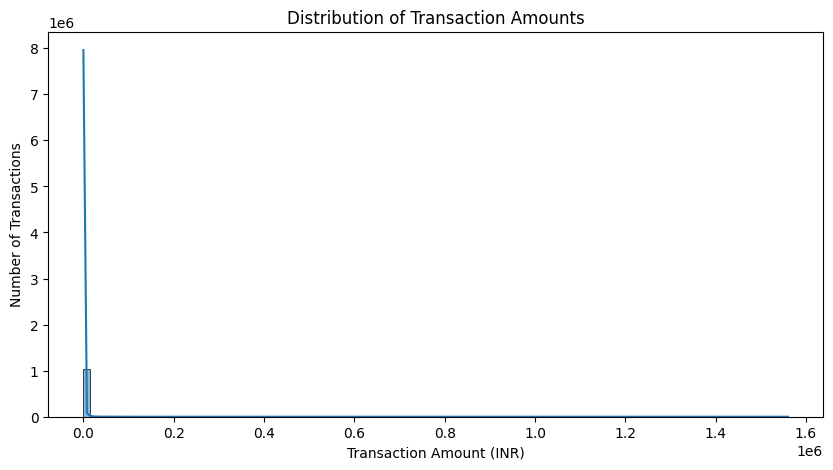

In [22]:
# Distribution of transaction amounts

plt.figure(figsize=(10, 5))

sns.histplot(
    df["TransactionAmount"],
    bins=100,
    kde=True
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (INR)")
plt.ylabel("Number of Transactions")

plt.show()

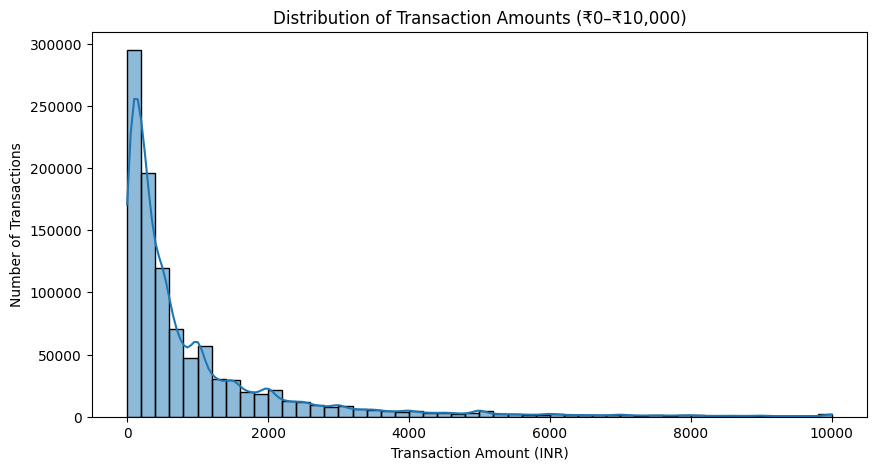

In [23]:
# Distribution of typical transaction amounts

transaction_zoom = df[df["TransactionAmount"] <= 10000]

plt.figure(figsize=(10, 5))

sns.histplot(
    transaction_zoom["TransactionAmount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amounts (₹0–₹10,000)")
plt.xlabel("Transaction Amount (INR)")
plt.ylabel("Number of Transactions")

plt.show()

CustLocation
MUMBAI       103595
NEW DELHI     84928
BANGALORE     81555
GURGAON       73818
DELHI         71019
NOIDA         32784
CHENNAI       30009
PUNE          25851
HYDERABAD     23049
THANE         21505
Name: count, dtype: int64


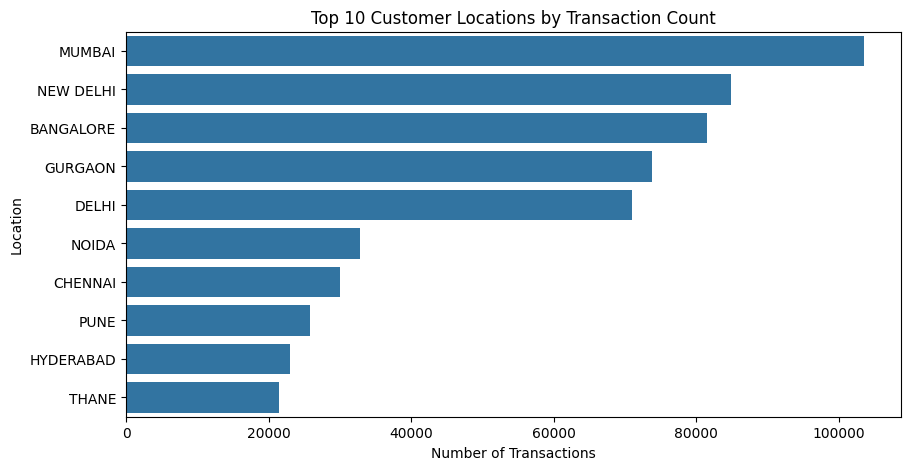

In [24]:
# Top 10 customer locations by transaction count

top_locations = df["CustLocation"].value_counts().head(10)

print(top_locations)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top 10 Customer Locations by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("Location")

plt.show()

Top 10 Locations by Total Transaction Value:
CustLocation
MUMBAI       1.796861e+08
NEW DELHI    1.607059e+08
BANGALORE    1.184248e+08
GURGAON      1.120947e+08
DELHI        1.062249e+08
KOLKATA      6.060031e+07
CHENNAI      4.463782e+07
NOIDA        4.446343e+07
PUNE         3.959035e+07
HYDERABAD    3.617739e+07
Name: TransactionAmount, dtype: float64


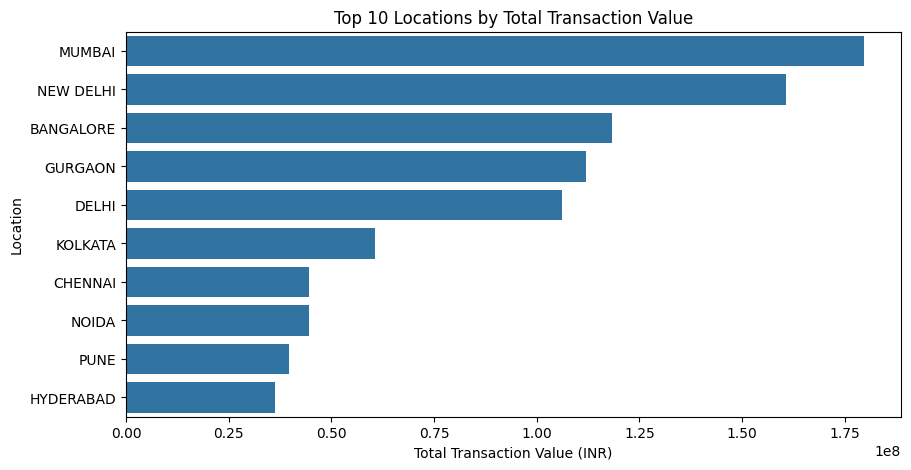

In [25]:
# Top 10 locations by total transaction value

location_value = (
    df.groupby("CustLocation")["TransactionAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Locations by Total Transaction Value:")
print(location_value)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=location_value.values,
    y=location_value.index
)

plt.title("Top 10 Locations by Total Transaction Value")
plt.xlabel("Total Transaction Value (INR)")
plt.ylabel("Location")

plt.show()

  TransactionDate  Transaction_Count  Transaction_Value
0         2016-08             653933       1.030599e+09
1         2016-09             390975       6.125312e+08
2         2016-10               3659       7.665019e+06


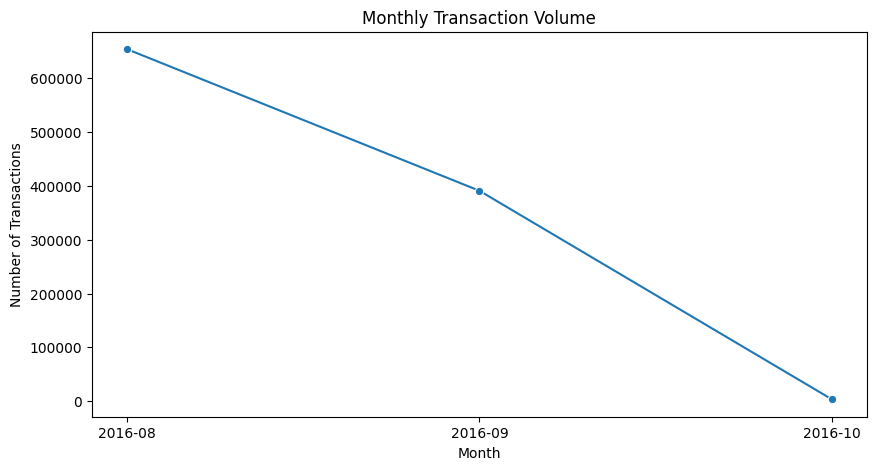

In [26]:
# Monthly transaction analysis

monthly_transactions = (
    df.groupby(df["TransactionDate"].dt.to_period("M"))
    .agg(
        Transaction_Count=("TransactionID", "count"),
        Transaction_Value=("TransactionAmount", "sum")
    )
    .reset_index()
)

monthly_transactions["TransactionDate"] = (
    monthly_transactions["TransactionDate"].astype(str)
)

print(monthly_transactions)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_transactions,
    x="TransactionDate",
    y="Transaction_Count",
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.show()

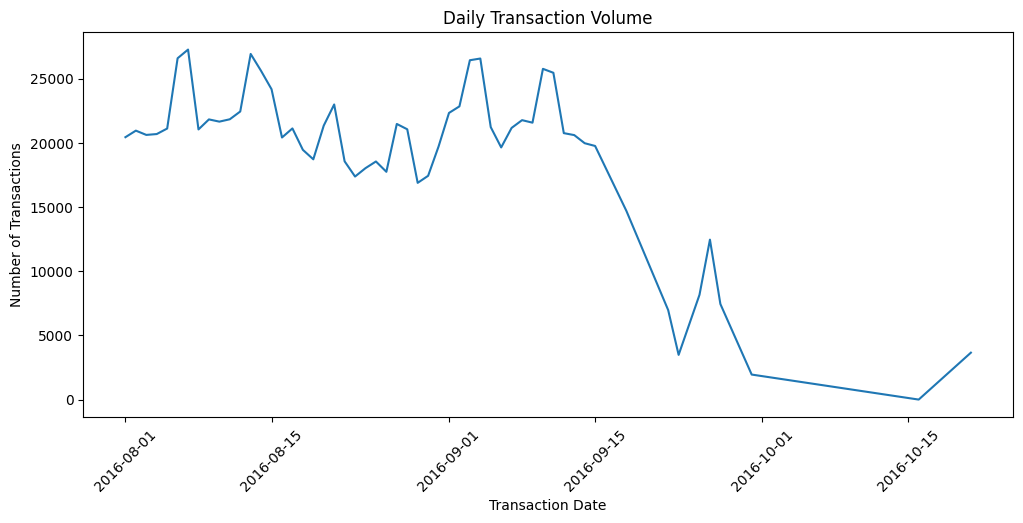

In [27]:
# Daily transaction volume

daily_transactions = (
    df.groupby("TransactionDate")["TransactionID"]
    .count()
    .reset_index(name="Transaction_Count")
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=daily_transactions,
    x="TransactionDate",
    y="Transaction_Count"
)

plt.title("Daily Transaction Volume")
plt.xlabel("Transaction Date")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

In [28]:
# Customer transaction frequency

customer_frequency = (
    df.groupby("CustomerID")["TransactionID"]
    .count()
    .value_counts()
    .sort_index()
)

print("Customer Transaction Frequency:")
print(customer_frequency.head(10))

print("\nCustomers with exactly 1 transaction:",
      (customer_frequency.index == 1).sum())

print("Customers with 2 transactions:",
      (customer_frequency.index == 2).sum())

print("Customers with 3+ transactions:",
      (customer_frequency.index >= 3).sum())

Customer Transaction Frequency:
TransactionID
1    740653
2    124960
3     16789
4      1702
5       147
6        14
Name: count, dtype: int64

Customers with exactly 1 transaction: 1
Customers with 2 transactions: 1
Customers with 3+ transactions: 4


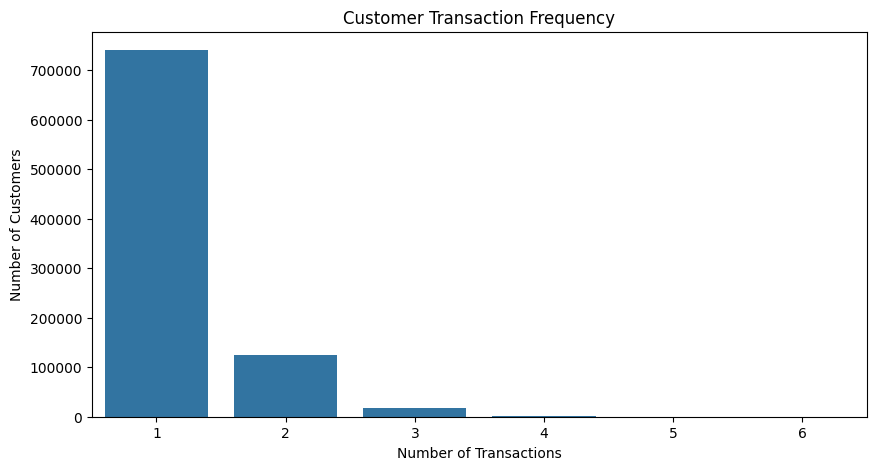

In [29]:
# Visualize customer transaction frequency

frequency_data = (
    df.groupby("CustomerID")["TransactionID"]
    .count()
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=frequency_data.index,
    y=frequency_data.values
)

plt.title("Customer Transaction Frequency")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

plt.show()

In [30]:
analysis_date = df["TransactionDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("CustomerID")
      .agg(
          Recency=("TransactionDate", lambda x: (analysis_date - x.max()).days),
          Frequency=("TransactionID", "count"),
          Monetary=("TransactionAmount", "sum")
      )
      .reset_index()
)

print("RFM table created successfully!")
print("\nFirst 5 customers:")
print(rfm.head())

print("\nRFM Statistics:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe())

RFM table created successfully!

First 5 customers:
  CustomerID  Recency  Frequency  Monetary
0   C1010011       26          2    5106.0
1   C1010012       69          1    1499.0
2   C1010014       76          2    1455.0
3   C1010018       37          1      30.0
4   C1010024       65          1    5000.0

RFM Statistics:
             Recency      Frequency      Monetary
count  884265.000000  884265.000000  8.842650e+05
mean       56.307305       1.185806  1.866856e+03
std        15.226654       0.450683  7.207210e+03
min         1.000000       1.000000  0.000000e+00
25%        44.000000       1.000000  2.000000e+02
50%        56.000000       1.000000  5.368000e+02
75%        69.000000       1.000000  1.500000e+03
max        82.000000       6.000000  1.560035e+06


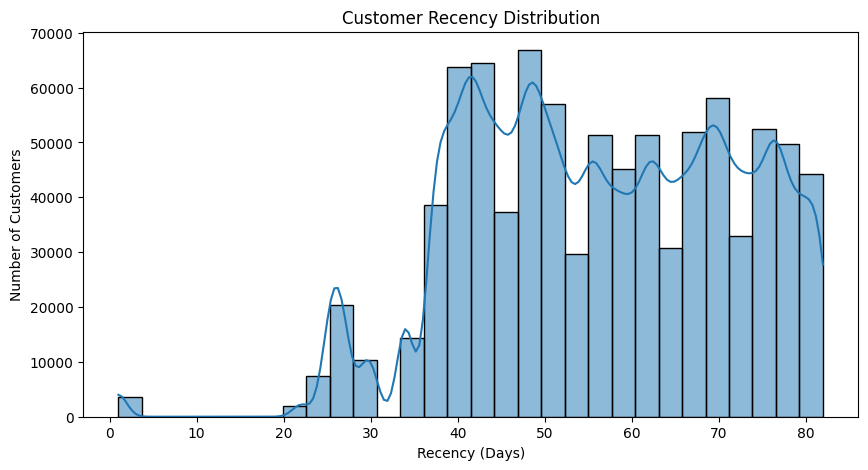

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    rfm["Recency"],
    bins=30,
    kde=True
)

plt.title("Customer Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.show()

Frequency Distribution:
Frequency
1    740653
2    124960
3     16789
4      1702
5       147
6        14
Name: count, dtype: int64


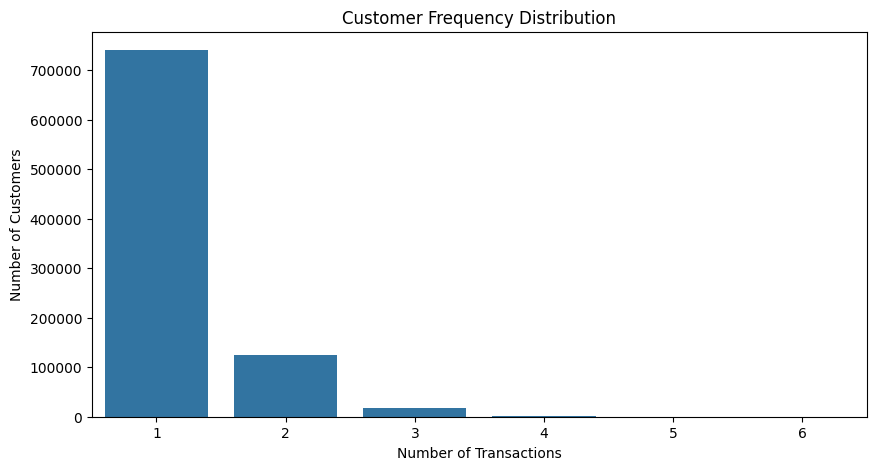

In [32]:
frequency_counts = rfm["Frequency"].value_counts().sort_index()

print("Frequency Distribution:")
print(frequency_counts)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=frequency_counts.index.astype(str),
    y=frequency_counts.values
)

plt.title("Customer Frequency Distribution")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")

plt.show()

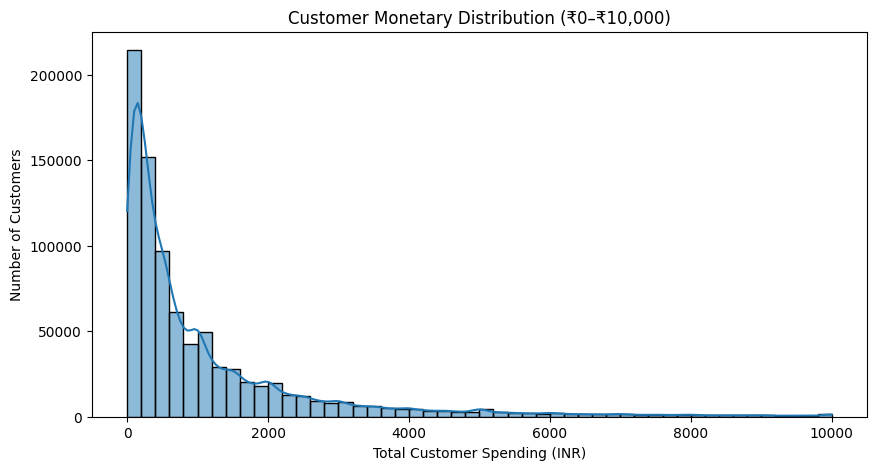

In [33]:
monetary_zoom = rfm[rfm["Monetary"] <= 10000]

plt.figure(figsize=(10, 5))

sns.histplot(
    monetary_zoom["Monetary"],
    bins=50,
    kde=True
)

plt.title("Customer Monetary Distribution (₹0–₹10,000)")
plt.xlabel("Total Customer Spending (INR)")
plt.ylabel("Number of Customers")

plt.show()

In [34]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

print(rfm.head())

print("\nRFM Scores created successfully!")

  CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score
0   C1010011       26          2    5106.0       5       5       5
1   C1010012       69          1    1499.0       2       1       4
2   C1010014       76          2    1455.0       1       5       4
3   C1010018       37          1      30.0       5       1       1
4   C1010024       65          1    5000.0       2       1       5

RFM Scores created successfully!


In [35]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

print("Combined RFM scores created successfully!")

print("\nSample RFM scores:")
print(
    rfm[
        ["CustomerID", "Recency", "Frequency", "Monetary",
         "R_Score", "F_Score", "M_Score", "RFM_Score"]
    ].head(10)
)

print("\nMost common RFM scores:")
print(rfm["RFM_Score"].value_counts().head(10))

Combined RFM scores created successfully!

Sample RFM scores:
  CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0   C1010011       26          2    5106.0       5       5       5       555
1   C1010012       69          1    1499.0       2       1       4       214
2   C1010014       76          2    1455.0       1       5       4       154
3   C1010018       37          1      30.0       5       1       1       511
4   C1010024       65          1    5000.0       2       1       5       215
5   C1010028       54          1     557.0       3       1       3       313
6   C1010031       79          2    1864.0       1       5       4       154
7   C1010035       56          2     750.0       3       5       3       353
8   C1010036       57          1     208.0       3       1       2       312
9   C1010037       74          1   19680.0       1       1       5       115

Most common RFM scores:
RFM_Score
555    21004
455    17138
554    15575
454    13096
355 

In [36]:
def assign_segment(row):
    R = int(row["R_Score"])
    F = int(row["F_Score"])
    M = int(row["M_Score"])

    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"
    elif R >= 4 and F >= 3:
        return "Loyal Customers"
    elif R >= 4 and F <= 2 and M >= 3:
        return "Potential Loyalists"
    elif R <= 2 and F >= 3:
        return "At Risk Customers"
    elif M >= 4:
        return "High Value Customers"
    elif R == 5 and F == 1:
        return "New Customers"
    else:
        return "Others"


rfm["Segment"] = rfm.apply(assign_segment, axis=1)

print("Customer segments created successfully!")

print("\nSegment Distribution:")
print(rfm["Segment"].value_counts())

print("\nSegment Percentage:")
print(
    (rfm["Segment"].value_counts(normalize=True) * 100)
    .round(2)
)

Customer segments created successfully!

Segment Distribution:
Segment
Others                  251410
At Risk Customers       187938
Loyal Customers         146615
High Value Customers    121189
Champions                89601
Potential Loyalists      72722
New Customers            14790
Name: count, dtype: int64

Segment Percentage:
Segment
Others                  28.43
At Risk Customers       21.25
Loyal Customers         16.58
High Value Customers    13.71
Champions               10.13
Potential Loyalists      8.22
New Customers            1.67
Name: proportion, dtype: float64


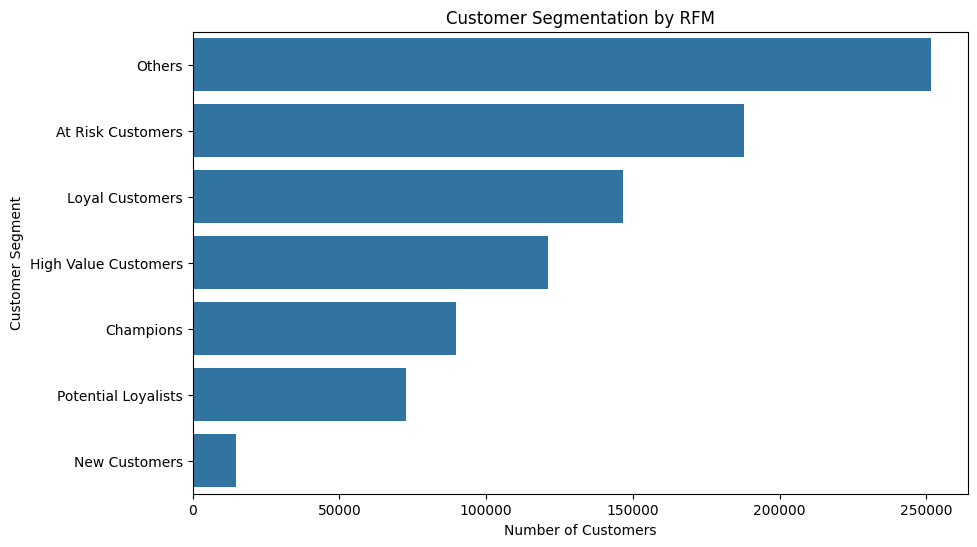

In [37]:
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.title("Customer Segmentation by RFM")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler

rfm_ml = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]].copy()

# Log transformation to reduce the effect of extreme values
rfm_ml["Monetary_Log"] = np.log1p(rfm_ml["Monetary"])

print("RFM data prepared for clustering!")

print("\nFirst 5 rows:")
print(rfm_ml.head())

print("\nFeatures used for clustering:")
print(rfm_ml[["Recency", "Frequency", "Monetary_Log"]].describe())

RFM data prepared for clustering!

First 5 rows:
  CustomerID  Recency  Frequency  Monetary  Monetary_Log
0   C1010011       26          2    5106.0      8.538367
1   C1010012       69          1    1499.0      7.313220
2   C1010014       76          2    1455.0      7.283448
3   C1010018       37          1      30.0      3.433987
4   C1010024       65          1    5000.0      8.517393

Features used for clustering:
             Recency      Frequency   Monetary_Log
count  884265.000000  884265.000000  884265.000000
mean       56.307305       1.185806       6.251212
std        15.226654       0.450683       1.612206
min         1.000000       1.000000       0.000000
25%        44.000000       1.000000       5.303305
50%        56.000000       1.000000       6.287487
75%        69.000000       1.000000       7.313887
max        82.000000       6.000000      14.260219


In [39]:
features = rfm_ml[[
    "Recency",
    "Frequency",
    "Monetary_Log"
]]

scaler = StandardScaler()

X = scaler.fit_transform(features)

print("RFM features standardized successfully!")

print("\nFirst 5 standardized rows:")
print(X[:5])

print("\nFeature means after scaling:")
print(X.mean(axis=0))

print("\nFeature standard deviations after scaling:")
print(X.std(axis=0))

RFM features standardized successfully!

First 5 standardized rows:
[[-1.99041245  1.80657726  1.41865034]
 [ 0.83358446 -0.4122771   0.65873037]
 [ 1.29330488  1.80657726  0.64026364]
 [-1.26799464 -0.4122771  -1.74743533]
 [ 0.57088707 -0.4122771   1.40564067]]

Feature means after scaling:
[2.26357357e-16 3.28808771e-17 7.02551526e-16]

Feature standard deviations after scaling:
[1. 1. 1.]


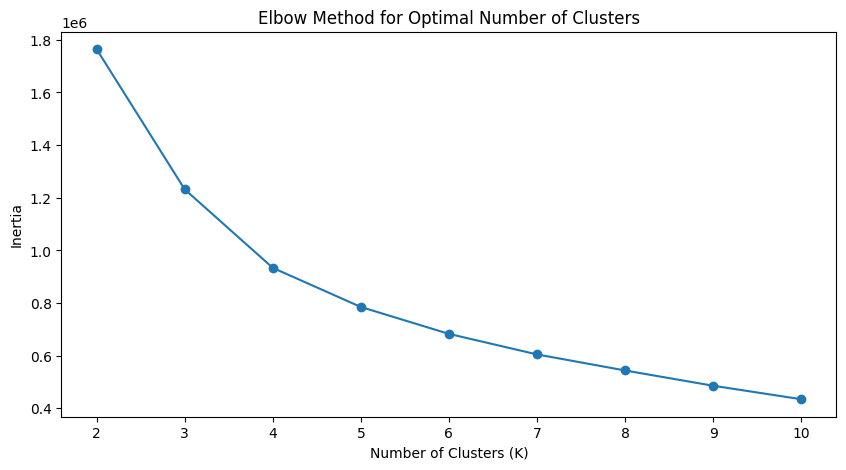

In [40]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(range(2, 11))

plt.show()

In [44]:
  print("K  |  Inertia")
print("-" * 20)

for k, value in zip(range(2, 11), inertia):
    print(f"{k}  |  {value:,.2f}")

K  |  Inertia
--------------------
2  |  1,764,351.93
3  |  1,231,977.99
4  |  933,735.61
5  |  785,137.47
6  |  682,916.33
7  |  604,880.25
8  |  543,885.66
9  |  485,903.54
10  |  434,638.76


In [46]:
from sklearn.metrics import silhouette_score

# Use a representative sample of 10,000 customers
sample_size = 10000

X_sample = X[
    np.random.RandomState(42).choice(
        X.shape[0],
        size=sample_size,
        replace=False
    )
]

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_sample = kmeans.fit_predict(X_sample)

    score = silhouette_score(X_sample, labels_sample)
    silhouette_scores.append(score)

print("K  |  Silhouette Score")
print("-" * 30)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"{k}  |  {score:.4f}")

K  |  Silhouette Score
------------------------------
2  |  0.4553
3  |  0.3666
4  |  0.3696
5  |  0.3525
6  |  0.3643
7  |  0.3427
8  |  0.3386
9  |  0.3346
10  |  0.3389


In [47]:
kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm_ml["Cluster"] = kmeans_final.fit_predict(X)

print("K-Means clustering completed successfully!")

print("\nCluster Distribution:")
print(rfm_ml["Cluster"].value_counts().sort_index())

K-Means clustering completed successfully!

Cluster Distribution:
Cluster
0    268191
1    273902
2    198940
3    143232
Name: count, dtype: int64


In [48]:
# Merge cluster labels with the main RFM dataset

rfm = rfm.merge(
    rfm_ml[["CustomerID", "Cluster"]],
    on="CustomerID",
    how="left"
)

# Create cluster profile
cluster_profile = (
    rfm.groupby("Cluster")
       .agg(
           Customers=("CustomerID", "count"),
           Avg_Recency=("Recency", "mean"),
           Avg_Frequency=("Frequency", "mean"),
           Avg_Monetary=("Monetary", "mean")
       )
       .round(2)
)

# Calculate percentage of customers
cluster_profile["Customer_Percentage"] = (
    cluster_profile["Customers"] / len(rfm) * 100
).round(2)

print("Cluster Profile:")
print(cluster_profile)

Cluster Profile:
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Cluster                                                        
0           268191        43.12           1.00       1918.76   
1           273902        70.89           1.00       2314.03   
2           198940        59.58           1.00         92.83   
3           143232        48.57           2.14       3378.55   

         Customer_Percentage  
Cluster                       
0                      30.33  
1                      30.98  
2                      22.50  
3                      16.20  


Cluster Metrics:
         Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                          
0              43.12           1.00       1918.76
1              70.89           1.00       2314.03
2              59.58           1.00         92.83
3              48.57           2.14       3378.55


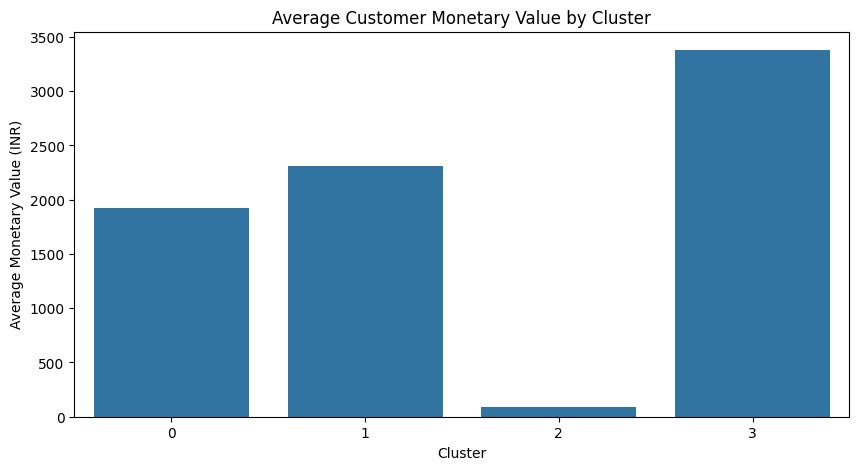

In [49]:
# Prepare cluster profile for visualization

cluster_metrics = cluster_profile[
    ["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]
]

print("Cluster Metrics:")
print(cluster_metrics)

# Plot average monetary value by cluster

plt.figure(figsize=(10, 5))

sns.barplot(
    x=cluster_metrics.index.astype(str),
    y=cluster_metrics["Avg_Monetary"].values
)

plt.title("Average Customer Monetary Value by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Monetary Value (INR)")

plt.show()

In [50]:
cluster_value = (
    rfm.groupby("Cluster")
       .agg(
           Customers=("CustomerID", "count"),
           Total_Monetary=("Monetary", "sum"),
           Avg_Monetary=("Monetary", "mean")
       )
       .reset_index()
)

cluster_value["Customer_Percentage"] = (
    cluster_value["Customers"] / len(rfm) * 100
).round(2)

cluster_value["Value_Percentage"] = (
    cluster_value["Total_Monetary"] / rfm["Monetary"].sum() * 100
).round(2)

cluster_value = cluster_value.round(2)

print("Cluster Value Contribution:")
print(cluster_value)

Cluster Value Contribution:
   Cluster  Customers  Total_Monetary  Avg_Monetary  Customer_Percentage  \
0        0     268191    5.145941e+08       1918.76                30.33   
1        1     273902    6.338174e+08       2314.03                30.98   
2        2     198940    1.846822e+07         92.83                22.50   
3        3     143232    4.839161e+08       3378.55                16.20   

   Value_Percentage  
0             31.17  
1             38.39  
2              1.12  
3             29.31  


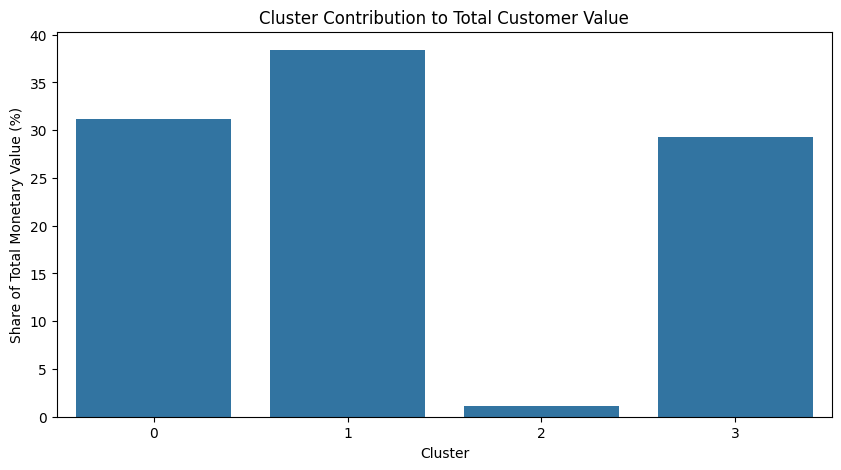

In [51]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=cluster_value,
    x="Cluster",
    y="Value_Percentage"
)

plt.title("Cluster Contribution to Total Customer Value")
plt.xlabel("Cluster")
plt.ylabel("Share of Total Monetary Value (%)")

plt.show()

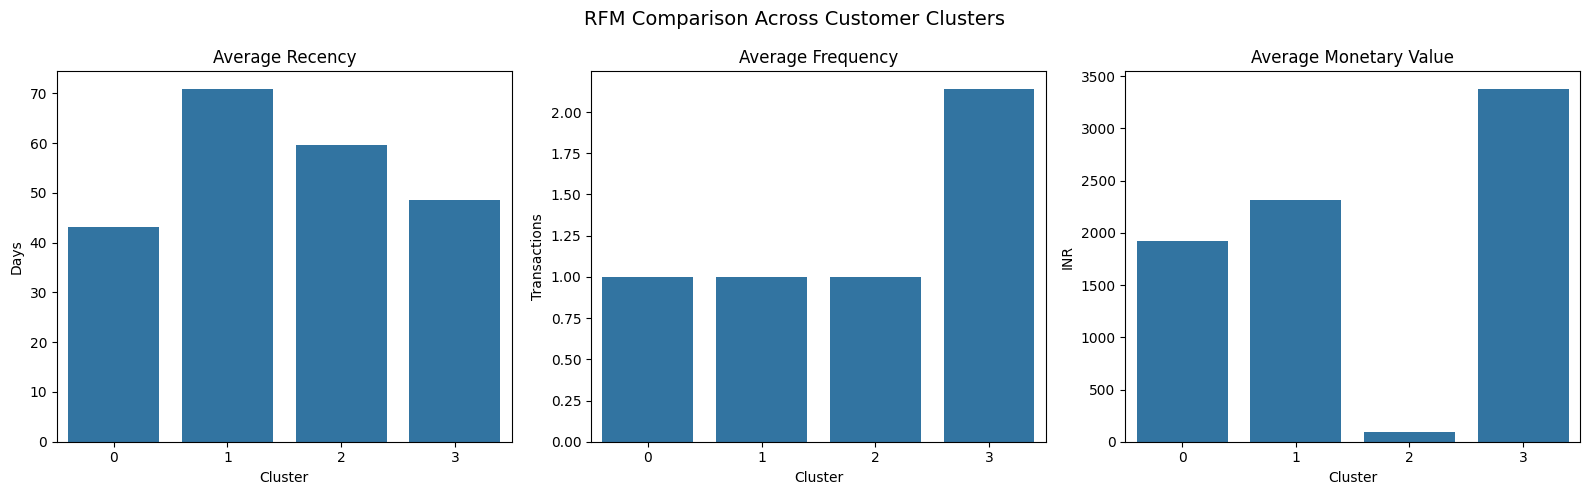

In [52]:
# Compare average RFM metrics across clusters

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(
    data=cluster_profile,
    x=cluster_profile.index,
    y="Avg_Recency",
    ax=axes[0]
)
axes[0].set_title("Average Recency")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Days")

sns.barplot(
    data=cluster_profile,
    x=cluster_profile.index,
    y="Avg_Frequency",
    ax=axes[1]
)
axes[1].set_title("Average Frequency")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Transactions")

sns.barplot(
    data=cluster_profile,
    x=cluster_profile.index,
    y="Avg_Monetary",
    ax=axes[2]
)
axes[2].set_title("Average Monetary Value")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("INR")

plt.suptitle("RFM Comparison Across Customer Clusters", fontsize=14)

plt.tight_layout()
plt.show()

# Marketing Recommendations

## Cluster 0 – Recent Moderate-Value Customers
- Customers have relatively recent transaction activity.
- Average transaction frequency is low at approximately 1 transaction.
- Strategy: Encourage repeat transactions through personalized product recommendations, cross-selling and targeted engagement campaigns.
- Objective: Increase transaction frequency and customer lifetime value.

## Cluster 1 – At-Risk Higher-Value Customers
- Customers have the highest average recency at approximately 71 days.
- Average monetary value is relatively high at approximately ₹2,314.
- This cluster contributes the highest share of total customer monetary value.
- Strategy: Use targeted reactivation campaigns, personalized offers and reminders to encourage customers to transact again.
- Objective: Reduce customer inactivity and retain valuable customers.

## Cluster 2 – Low-Value / Low-Engagement Customers
- Customers show low average monetary value of approximately ₹93.
- Average transaction frequency is approximately 1 transaction.
- Strategy: Use cost-efficient engagement campaigns and cross-selling opportunities rather than high-cost retention campaigns.
- Objective: Gradually increase engagement and customer value.

## Cluster 3 – Frequent High-Value Customers
- Customers have the highest average transaction frequency at approximately 2.14.
- They also have the highest average monetary value at approximately ₹3,379.
- Strategy: Focus on retention, loyalty benefits, premium products and personalized banking offers.
- Objective: Maintain engagement and strengthen long-term customer relationships.

# Key Business Insights

1. The dataset contains 1,048,567 transactions from 884,265 unique customers.

2. Transaction values are highly right-skewed, with a small number of very high-value transactions contributing to the long tail.

3. Approximately 83.8% of customers have only one recorded transaction, indicating relatively low observed transaction frequency in the dataset.

4. RFM analysis revealed substantial differences in customer recency, frequency and monetary value.

5. K-Means clustering identified four customer groups with distinct behavioural characteristics.

6. Cluster 1 has the highest average recency and the highest contribution to total customer monetary value, highlighting a potential customer reactivation opportunity.

7. Cluster 3 has the highest average transaction frequency and monetary value, making retention and loyalty strategies relevant for this group.

8. The segmentation demonstrates how transaction-level data can be transformed into actionable customer groups for targeted marketing.